# Day 08. Exercise 04
# Regression

## 0. Imports

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [6]:
# !gdown 1L8auBzJEghWFewznhhFpcrqxW4GqcfRY -O '../data/checker_regression.csv'

In [7]:
df = pd.read_csv('../data/checker_regression.csv').fillna(0)
df = df.groupby('uid').first()
X = df.drop(columns=['AVG(diff)'], axis=1)
y = df['AVG(diff)']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, user_1 to user_8
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0+ bytes


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [ ]:
def crossval(n_splits,X,y,model):
    kf = KFold(n_splits)
    err_list = []
    for train_idx, test_idx in kf.split(X):
        model.fit(X.iloc[train_idx],y.iloc[train_idx])
        err_train = root_mean_squared_error(y.iloc[train_idx],model.predict(X.iloc[train_idx]))
        err_test = root_mean_squared_error(y.iloc[test_idx],model.predict(X.iloc[test_idx]))
        err_list.append(err_test)
        print("train -", err_train, "|", "test -", err_test)
    print("Average RMSE on crossval is", np.mean(err_list))

In [18]:
lin = LinearRegression(fit_intercept=False)
crossval(10, X, y, lin)

train - 75.2435032474818 | test - 32.3267903052748
train - 75.82039461058449 | test - 16.51539314022958
train - 75.61776836472133 | test - 22.9936330663752
train - 70.23376898826521 | test - 88.32747128354801
train - 69.82808185925116 | test - 89.03413627284623
train - 64.13559687271743 | test - 121.10769471519383
train - 75.67255211996402 | test - 21.563263358000015
train - 70.70650589900161 | test - 99.71032860779489
train - 70.30993671210766 | test - 85.61597746049623
train - 69.22852671072529 | test - 103.97839471486641
Average RMSE on crossval is 68.11730829246252
KFold(n_splits=10, random_state=None, shuffle=False)


In [11]:
destr = DecisionTreeRegressor(random_state=21, max_depth=4)
crossval(10, X, y, destr)

train - 26.351045958701963 | test - 56.43598881328592
train - 27.90447105726527 | test - 42.98854498584477
train - 21.276290674640514 | test - 68.09602152951484
train - 28.930703876342633 | test - 39.91895986221937
train - 23.518839397894013 | test - 76.68265065865315
train - 30.300574318472975 | test - 105.20663716564513
train - 29.90328710477043 | test - 99.13004739379627
train - 26.644564291198424 | test - 54.49705415925743
train - 30.185906529230703 | test - 79.14935015292058
train - 22.830665883811115 | test - 103.79675490170683
Average RMSE on crossval is 72.59020096228441


In [12]:
rnf = RandomForestRegressor(random_state=21, max_depth=25, n_estimators=100)
crossval(10, X, y, rnf)

train - 23.376588725112924 | test - 54.188682625310854
train - 24.786329836610147 | test - 51.43619912958321
train - 23.572511158674967 | test - 78.22862076797261
train - 26.323072156014952 | test - 46.58363167823367
train - 23.84950304426348 | test - 53.93331786876579
train - 22.641636132615332 | test - 81.48666845609826
train - 22.829456547291223 | test - 85.3559750485078
train - 24.94655657217563 | test - 55.465009767253115
train - 23.615772901496197 | test - 58.201884439709815
train - 23.172034433072298 | test - 94.73684722371169
Average RMSE on crossval is 65.96168370051468


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [13]:
pred = pd.DataFrame({
    "AVG(diff)" : y_test,
    'lin' : lin.predict(X_test),
    'destr' : destr.predict(X_test),
    'rnf' : rnf.predict(X_test)
}
)

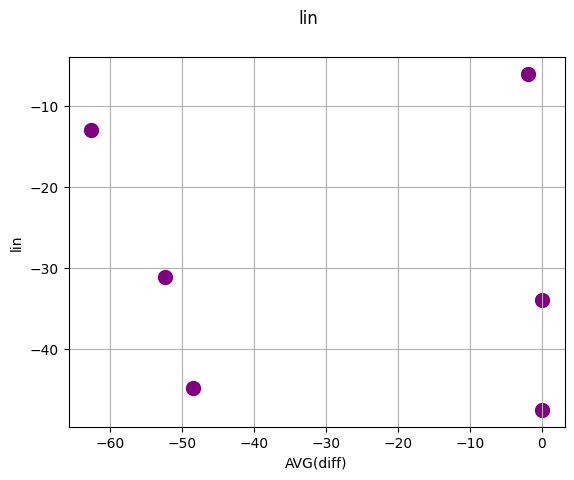

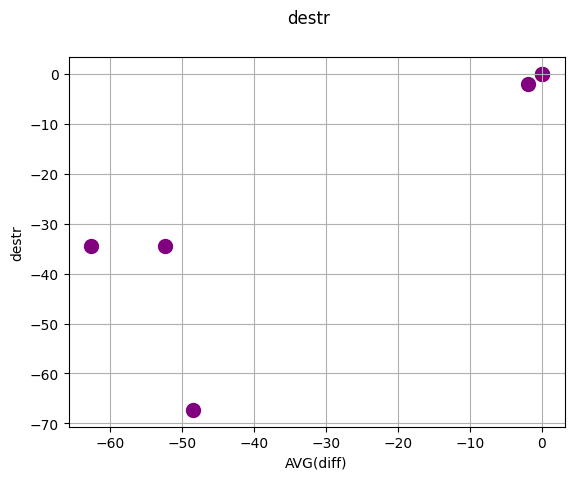

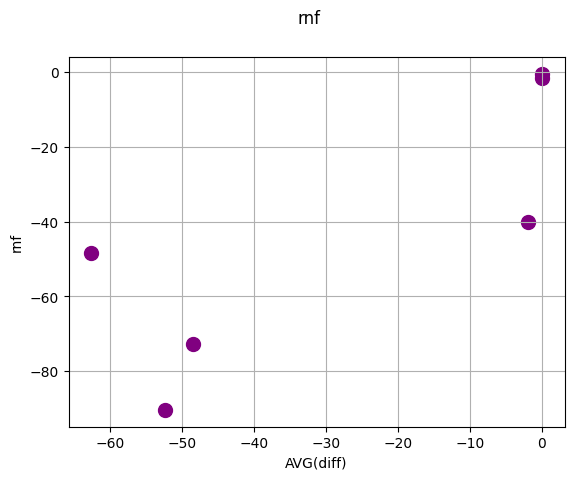

In [14]:
for model in pred.drop(columns='AVG(diff)').columns:
    pred.plot(kind='scatter',x='AVG(diff)',y=model,grid = True, color = 'purple', s = 100)
    plt.suptitle(model)

ideal should be a diagonal y=x